# Transformer Training – Circuit Breaker Health Classification
Binäre Klassifikation: **0 = gesund**, **1 = defekt** (letzte 100 Kurven)

In [2]:
import numpy as np                          # wie MATLAB selbst – Arrays, Mathe, linspace usw.
import matplotlib.pyplot as plt             # wie 'plot()' in MATLAB – zum Zeichnen von Grafiken
import torch                                # PyTorch – die ML-Bibliothek für neuronale Netze
import torch.nn as nn                       # nn = neural network – enthält Layer, Loss-Funktionen usw.
from torch.utils.data import Dataset, DataLoader   # Dataset: Datenbehälter; DataLoader: gibt Batches raus
from sklearn.model_selection import train_test_split  # teilt Daten automatisch in Train/Test auf
from sklearn.metrics import classification_report, confusion_matrix  # Auswertungs-Tools nach dem Training
import seaborn as sns                       # Erweiterung für schönere Plots (wie besseres MATLAB-Figure)

## Schritt 1: Datensatz generieren (mit Rauschen & Verzerrung)

Dataset Shape: (1000, 500)
SoH: 1.0 bei i=0, 0.0 bei i=900 (Defektgrenze), 0.0 bei i=999 (geclippt)


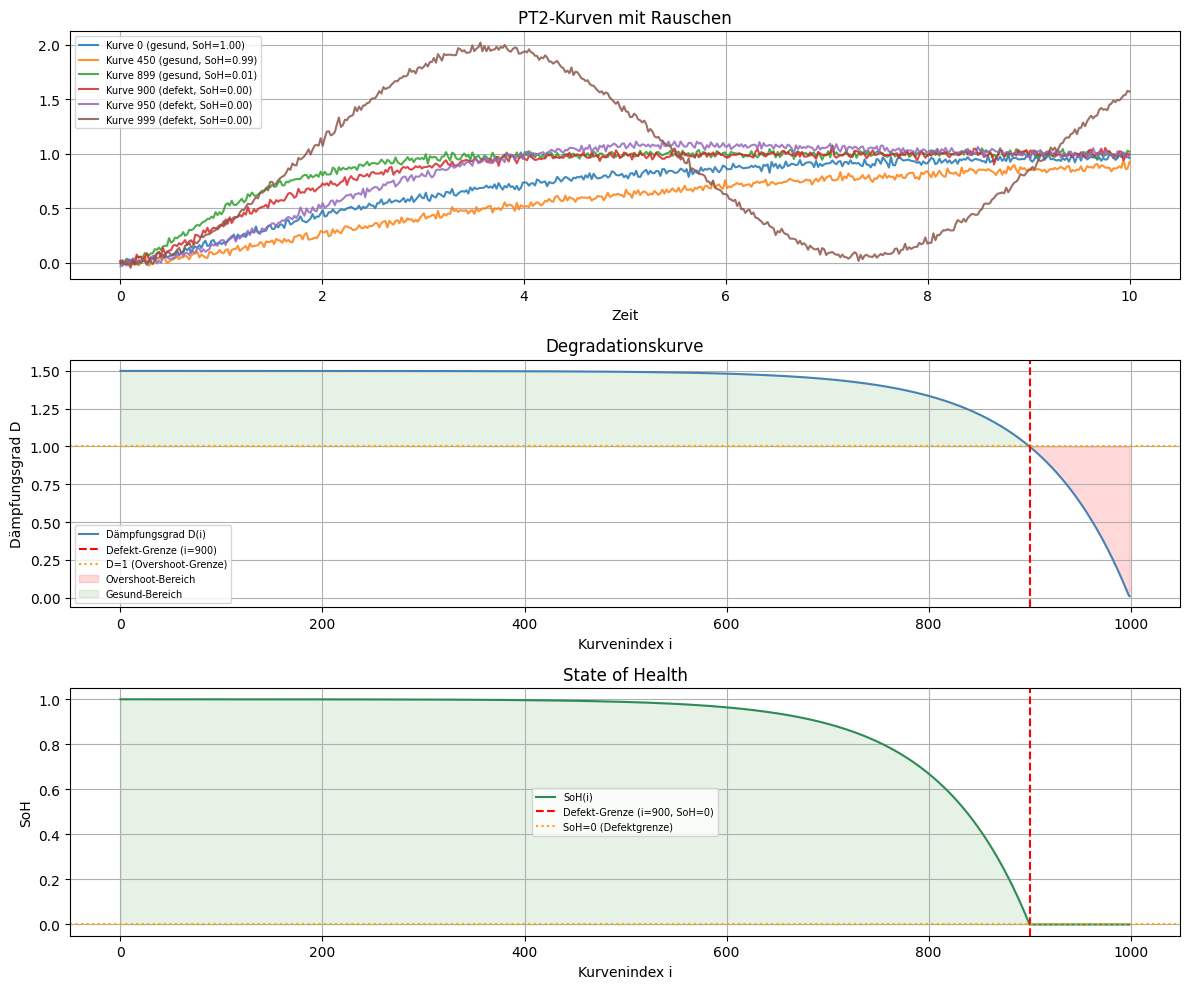

In [3]:
np.random.seed(42)

n_curves = 1000
t = np.linspace(0, 10, 500)
SEQ_LEN = len(t)

K = 1.0

# D(i) = C - A * exp(k*i), differenzierbar
# Randbedingungen: D(0)=1.5, D(900)=1.0, D(999)≈0
k_opt = 0.01109
A = 0.5 / (np.exp(900 * k_opt) - 1)
C = A + 1.5

i_all    = np.arange(n_curves)
D_values = np.clip(C - A * np.exp(k_opt * i_all), 0.01, None)

D_start     = D_values[0]   # ≈ 1.5
D_threshold = 1.0           # Overshoot-Grenze

# SoH = 1.0 bei i=0 (perfekt gesund), SoH = 0.0 bei i=900 (Defektgrenze), <0 geclippt
soh_values    = np.clip((D_values - D_threshold) / (D_start - D_threshold), 0.0, 1.0).astype(np.float32)
SOH_THRESHOLD = 0.0         # SoH=0 → Defektgrenze

T_values = np.random.uniform(0.5, 2.0, n_curves)

def pt2_step(t, K, T, D):
    """PT2-Sprungantwort analytisch: G(s) = K / (T²s² + 2DTs + 1)"""
    w0 = 1.0 / T
    if D > 1.0:
        wd = w0 * np.sqrt(D**2 - 1)
        y = K * (1 - np.exp(-D*w0*t) * (np.cosh(wd*t) + (D/np.sqrt(D**2-1))*np.sinh(wd*t)))
    elif D == 1.0:
        y = K * (1 - (1 + w0*t) * np.exp(-w0*t))
    else:
        wd = w0 * np.sqrt(1 - D**2)
        y = K * (1 - np.exp(-D*w0*t) * (np.cos(wd*t) + (D/np.sqrt(1-D**2))*np.sin(wd*t)))
    return y

dataset = np.zeros((n_curves, len(t)))

for i in range(n_curves):
    clean      = pt2_step(t, K, T_values[i], D_values[i])
    dataset[i] = clean + np.random.normal(0, 0.02, len(t))

print(f"Dataset Shape: {dataset.shape}")
print(f"SoH: 1.0 bei i=0, 0.0 bei i=900 (Defektgrenze), 0.0 bei i=999 (geclippt)")

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# ── Plot 1: PT2-Kurven ────────────────────────────────────────────────────────
for idx in [0, 450, 899, 900, 950, 999]:
    tag = 'gesund' if soh_values[idx] > SOH_THRESHOLD else 'defekt'
    axes[0].plot(t, dataset[idx], label=f'Kurve {idx} ({tag}, SoH={soh_values[idx]:.2f})', alpha=0.85)
axes[0].set_title('PT2-Kurven mit Rauschen')
axes[0].set_xlabel('Zeit')
axes[0].legend(fontsize=7)
axes[0].grid(True)

# ── Plot 2: Degradationskurve D(i) ───────────────────────────────────────────
axes[1].plot(i_all, D_values, color='steelblue', label='Dämpfungsgrad D(i)')
axes[1].axvline(x=900, color='red',    linestyle='--', label='Defekt-Grenze (i=900)')
axes[1].axhline(y=1.0, color='orange', linestyle=':',  label='D=1 (Overshoot-Grenze)')
axes[1].fill_between(i_all, D_values, 1.0, where=(D_values < 1.0),  alpha=0.15, color='red',   label='Overshoot-Bereich')
axes[1].fill_between(i_all, D_values, 1.0, where=(D_values >= 1.0), alpha=0.1,  color='green', label='Gesund-Bereich')
axes[1].set_title('Degradationskurve')
axes[1].set_xlabel('Kurvenindex i')
axes[1].set_ylabel('Dämpfungsgrad D')
axes[1].legend(fontsize=7)
axes[1].grid(True)

# ── Plot 3: State of Health ───────────────────────────────────────────────────
axes[2].plot(i_all, soh_values, color='seagreen', label='SoH(i)')
axes[2].axvline(x=900, color='red',    linestyle='--', label='Defekt-Grenze (i=900, SoH=0)')
axes[2].axhline(y=0.0, color='orange', linestyle=':',  label='SoH=0 (Defektgrenze)')
axes[2].fill_between(i_all, soh_values, 0, where=(soh_values > 0), alpha=0.1, color='green')
axes[2].set_title('State of Health')
axes[2].set_xlabel('Kurvenindex i')
axes[2].set_ylabel('SoH')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(fontsize=7)
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Schritt 2: Dataset & DataLoader

In [4]:
data_min = dataset.min(axis=1, keepdims=True)
data_max = dataset.max(axis=1, keepdims=True)
dataset_norm = (dataset - data_min) / (data_max - data_min + 1e-8)

# Binaere Labels: 0 = gesund, 1 = defekt (letzte 100 Kurven, SoH=0)
labels = (soh_values <= SOH_THRESHOLD).astype(np.float32)

X_train, X_test, y_soh_train, y_soh_test, y_lbl_train, y_lbl_test = train_test_split(
    dataset_norm, soh_values, labels,
    test_size=0.2, random_state=42, stratify=labels.astype(int)
)

class CurveDataset(Dataset):
    """
    Gibt pro Sample zurueck:
      - masked_curve : Kurve mit Nullen ab cutoff          [SEQ_LEN, 1]
      - mask         : 1=bekannt, 0=vorherzusagen           [SEQ_LEN]
      - full_curve   : echte vollstaendige Kurve            [SEQ_LEN]
      - y_soh        : State of Health                      Skalar
      - y_lbl        : 0=gesund / 1=defekt                  Skalar

    cutoff_range : (min, max) fuer zufaelligen Schnittindex beim Training.
    fixed_cutoff : falls gesetzt, wird immer dieser Cutoff verwendet (Eval/Inference).
    """
    def __init__(self, X, y_soh, y_lbl, cutoff_range=(50, 450), fixed_cutoff=None):
        self.X           = torch.tensor(X,     dtype=torch.float32)  # [N, SEQ_LEN]
        self.y_soh       = torch.tensor(y_soh, dtype=torch.float32)
        self.y_lbl       = torch.tensor(y_lbl, dtype=torch.float32)
        self.cutoff_range  = cutoff_range
        self.fixed_cutoff  = fixed_cutoff

    def __len__(self):
        return len(self.y_soh)

    def __getitem__(self, idx):
        curve = self.X[idx]                        # [SEQ_LEN]
        if self.fixed_cutoff is not None:
            cutoff = self.fixed_cutoff
        else:
            cutoff = torch.randint(self.cutoff_range[0], self.cutoff_range[1] + 1, (1,)).item()

        mask = torch.zeros(len(curve))
        mask[:cutoff] = 1.0                        # 1 = bekannt

        masked_curve = curve.clone()
        masked_curve[cutoff:] = 0.0                # unbekannte Schritte auf 0 setzen

        return (
            masked_curve.unsqueeze(-1),            # [SEQ_LEN, 1]
            mask,                                  # [SEQ_LEN]
            curve,                                 # [SEQ_LEN]  (Ziel fuer Forecast)
            self.y_soh[idx],
            self.y_lbl[idx],
        )

# Training: zufaelliger Cutoff zwischen 50 und 450
# Validation: fester Cutoff bei 200 fuer reproduzierbare Metriken
train_loader = DataLoader(
    CurveDataset(X_train, y_soh_train, y_lbl_train, cutoff_range=(50, 450)),
    batch_size=32, shuffle=True
)
test_loader = DataLoader(
    CurveDataset(X_test, y_soh_test, y_lbl_test, fixed_cutoff=200),
    batch_size=64, shuffle=False
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Defekt im Train: {y_lbl_train.sum():.0f}, Defekt im Test: {y_lbl_test.sum():.0f}")
print(f"Beispiel-Batch: {next(iter(train_loader))[0].shape}")


Train: 800, Test: 200
Defekt im Train: 80, Defekt im Test: 20
Beispiel-Batch: torch.Size([32, 500, 1])


## Schritt 3: Transformer Modell

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class CircuitBreakerTransformer(nn.Module):
    """
    Multitask Transformer:
      - Eingang : maskierte Kurve [B, SEQ_LEN, 1] + Maske [B, SEQ_LEN]
                  (Kanal 0 = Kurvenwert, Kanal 1 = Maske 1=bekannt/0=unbekannt)
      - Ausgang 1 (forecast) : vollstaendige Kurve [B, SEQ_LEN]  (Vorhersage der unbekannten Schritte)
      - Ausgang 2 (soh)      : State of Health [B]  (0=defekt, 1=gesund)
      - Ausgang 3 (prob)     : Defekt-Wahrscheinlichkeit [B]  (>0.5 = defekt)
    """
    def __init__(self, seq_len=500, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(2, d_model)   # 2 Kanaele: Wert + Maske
        self.pos_enc    = PositionalEncoding(d_model, max_len=seq_len)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Kopf 1: Kurven-Vorhersage (ein Wert pro Zeitschritt)
        self.forecaster = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        # Kopf 2: SoH-Regression
        self.regressor = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1), nn.Sigmoid()
        )
        # Kopf 3: Defekt-Klassifikation
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1), nn.Sigmoid()
        )

    def forward(self, x, mask):
        # x    : [B, SEQ_LEN, 1]
        # mask : [B, SEQ_LEN]  (1=bekannt, 0=vorherzusagen)
        inp      = torch.cat([x, mask.unsqueeze(-1)], dim=-1)  # [B, SEQ_LEN, 2]
        inp      = self.input_proj(inp)                        # [B, SEQ_LEN, d_model]
        inp      = self.pos_enc(inp)
        features = self.transformer(inp)                       # [B, SEQ_LEN, d_model]

        forecast = self.forecaster(features).squeeze(-1)       # [B, SEQ_LEN]
        pooled   = features.mean(dim=1)                        # [B, d_model]
        soh      = self.regressor(pooled).squeeze(-1)          # [B]
        prob     = self.classifier(pooled).squeeze(-1)         # [B]
        return forecast, soh, prob


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = CircuitBreakerTransformer().to(device)
print(model)
print(f"\nParameter: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {device}")


CircuitBreakerTransformer(
  (input_proj): Linear(in_features=2, out_features=64, bias=True)
  (pos_enc): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (forecaster): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features

## Schritt 4: Training

In [6]:
crit_forecast = nn.MSELoss()
crit_soh      = nn.MSELoss()
crit_cls      = nn.BCELoss()
optimizer     = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler     = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for X_masked, mask, X_full, y_soh, y_lbl in loader:
        X_masked, mask   = X_masked.to(device), mask.to(device)
        X_full           = X_full.to(device)
        y_soh, y_lbl     = y_soh.to(device), y_lbl.to(device)

        optimizer.zero_grad()
        forecast, soh_pred, cls_pred = model(X_masked, mask)

        # Forecast-Loss nur auf den unbekannten Positionen berechnen
        unknown = (mask == 0)                          # [B, SEQ_LEN] bool
        loss_f  = crit_forecast(forecast[unknown], X_full[unknown])
        loss_s  = crit_soh(soh_pred, y_soh)
        loss_c  = crit_cls(cls_pred, y_lbl)
        loss    = loss_f + loss_s + loss_c

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_soh)
        correct    += ((cls_pred >= 0.5) == y_lbl.bool()).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    for X_masked, mask, X_full, y_soh, y_lbl in loader:
        X_masked, mask = X_masked.to(device), mask.to(device)
        X_full         = X_full.to(device)
        y_soh, y_lbl   = y_soh.to(device), y_lbl.to(device)

        forecast, soh_pred, cls_pred = model(X_masked, mask)
        unknown = (mask == 0)
        loss = (crit_forecast(forecast[unknown], X_full[unknown])
                + crit_soh(soh_pred, y_soh)
                + crit_cls(cls_pred, y_lbl))
        total_loss += loss.item() * len(y_soh)
        correct    += ((cls_pred >= 0.5) == y_lbl.bool()).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

n_epochs = 30
history  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, n_epochs + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    va_loss, va_acc = eval_epoch(model, test_loader)
    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | Train Loss: {tr_loss:.5f} Acc: {tr_acc:.3f} | Val Loss: {va_loss:.5f} Acc: {va_acc:.3f}")


Epoch 05 | Train Loss: 0.45448 Acc: 0.900 | Val Loss: 0.43825 Acc: 0.900
Epoch 10 | Train Loss: 0.41260 Acc: 0.900 | Val Loss: 0.36675 Acc: 0.900
Epoch 15 | Train Loss: 0.20797 Acc: 0.966 | Val Loss: 0.14713 Acc: 0.975
Epoch 20 | Train Loss: 0.18631 Acc: 0.968 | Val Loss: 0.14596 Acc: 0.975
Epoch 25 | Train Loss: 0.16568 Acc: 0.968 | Val Loss: 0.13085 Acc: 0.975
Epoch 30 | Train Loss: 0.15435 Acc: 0.971 | Val Loss: 0.12784 Acc: 0.980


## Modell speichern / laden
**Nach dem Training:** Die "Speichern"-Zelle ausführen.  
**Beim nächsten Start:** Nur Zellen 1–3 (Imports + Klassen) ausführen, dann die "Laden"-Zelle – Training überspringen.

In [7]:
# ── Modell SPEICHERN (nach dem Training einmal ausfuehren) ─────────────────────
torch.save({
    'model_state_dict': model.state_dict(),
    'SEQ_LEN': SEQ_LEN,
}, 'circuit_breaker_model.pth')

np.save('dataset_norm.npy', dataset_norm)
np.save('soh_values.npy',   soh_values)
np.save('labels.npy',       labels)

print('Modell und Datensatz gespeichert!')


Modell und Datensatz gespeichert!


In [8]:
# ── Modell LADEN (statt Training – Zellen 1-3 vorher ausführen!) ───────────
checkpoint = torch.load('circuit_breaker_model.pth', weights_only=True)
SEQ_LEN = checkpoint['SEQ_LEN']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CircuitBreakerTransformer(seq_len=SEQ_LEN).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

dataset_norm = np.load('dataset_norm.npy')
soh_values   = np.load('soh_values.npy')

print(f"Modell geladen! SEQ_LEN={SEQ_LEN}, Kurven={len(dataset_norm)}, Device={device}")

Modell geladen! SEQ_LEN=500, Kurven=1000, Device=cpu


## Schritt 5: Auswertung

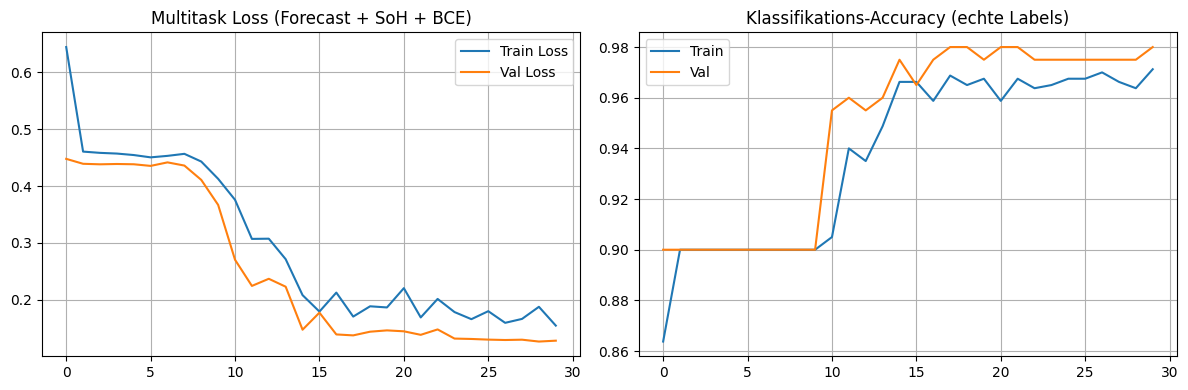

SoH MAE: 0.1137  |  SoH R2: 0.6618
              precision    recall  f1-score   support

      gesund       0.98      1.00      0.99       180
      defekt       1.00      0.80      0.89        20

    accuracy                           0.98       200
   macro avg       0.99      0.90      0.94       200
weighted avg       0.98      0.98      0.98       200



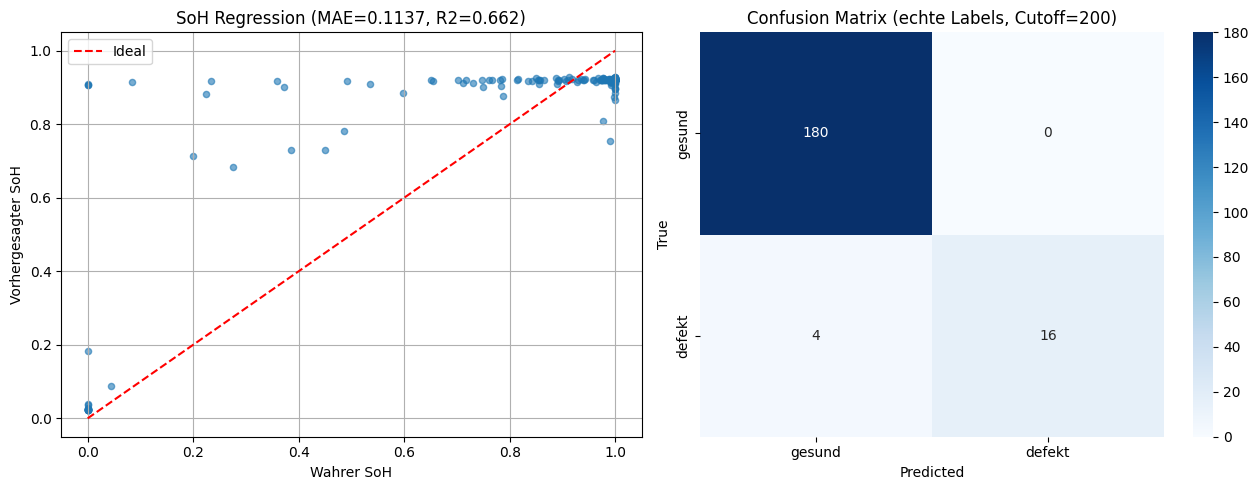

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

# ── Loss & Accuracy ueber Epochen ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Multitask Loss (Forecast + SoH + BCE)')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Klassifikations-Accuracy (echte Labels)')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

# ── Vorhersagen sammeln (fester Cutoff 200) ───────────────────────────────
model.eval()
all_soh_preds, all_soh_true = [], []
all_cls_preds, all_cls_true = [], []
with torch.no_grad():
    for X_masked, mask, X_full, y_soh, y_lbl in test_loader:
        X_masked, mask = X_masked.to(device), mask.to(device)
        _, soh_pred, cls_pred = model(X_masked, mask)
        all_soh_preds.extend(soh_pred.cpu().numpy())
        all_soh_true.extend(y_soh.numpy())
        all_cls_preds.extend(cls_pred.cpu().numpy())
        all_cls_true.extend(y_lbl.numpy())

all_soh_preds = np.array(all_soh_preds)
all_soh_true  = np.array(all_soh_true)
all_cls_preds = np.array(all_cls_preds)
all_cls_true  = np.array(all_cls_true).astype(int)

mae = mean_absolute_error(all_soh_true, all_soh_preds)
r2  = r2_score(all_soh_true, all_soh_preds)
print(f"SoH MAE: {mae:.4f}  |  SoH R2: {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(all_soh_true, all_soh_preds, alpha=0.6, s=20)
axes[0].plot([0, 1], [0, 1], 'r--', label='Ideal')
axes[0].set_xlabel('Wahrer SoH'); axes[0].set_ylabel('Vorhergesagter SoH')
axes[0].set_title(f'SoH Regression (MAE={mae:.4f}, R2={r2:.3f})')
axes[0].legend(); axes[0].grid(True)

pred_labels = (all_cls_preds >= 0.5).astype(int)
print(classification_report(all_cls_true, pred_labels, target_names=['gesund', 'defekt']))
cm = confusion_matrix(all_cls_true, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['gesund', 'defekt'], yticklabels=['gesund', 'defekt'])
axes[1].set_title('Confusion Matrix (echte Labels, Cutoff=200)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.show()


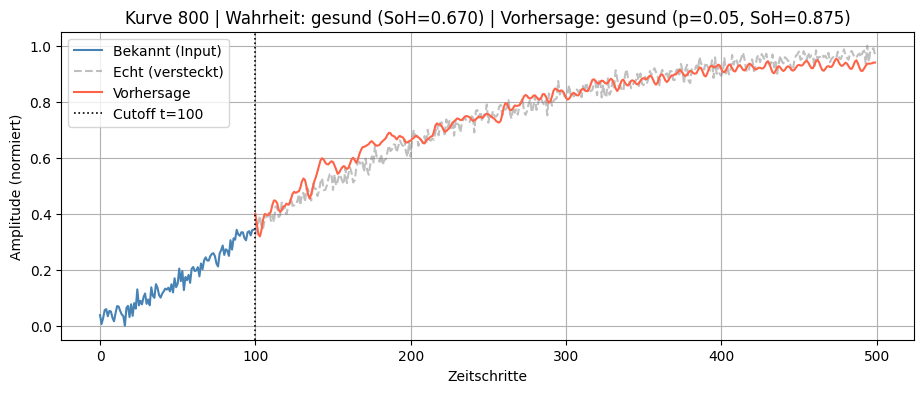

In [40]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class CircuitBreakerTransformer(nn.Module):
    def __init__(self, seq_len=500, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(2, d_model)
        self.pos_enc     = PositionalEncoding(d_model, max_len=seq_len)
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.forecaster  = nn.Sequential(nn.Linear(d_model, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))
        self.regressor   = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1), nn.Sigmoid())
        self.classifier  = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1), nn.Sigmoid())
    def forward(self, x, mask):
        inp      = torch.cat([x, mask.unsqueeze(-1)], dim=-1)
        inp      = self.pos_enc(self.input_proj(inp))
        features = self.transformer(inp)
        forecast = self.forecaster(features).squeeze(-1)
        pooled   = features.mean(dim=1)
        return forecast, self.regressor(pooled).squeeze(-1), self.classifier(pooled).squeeze(-1)

# ── Einstellungen ────────────────────────────────────────────────────────────
idx    = 800   # <- Kurvenindex (0-999)
cutoff = 100   # <- bekannte Zeitschritte (z.B. 100, 200, 300)

# ── Laden ────────────────────────────────────────────────────────────────────
checkpoint   = torch.load('circuit_breaker_model.pth', weights_only=True)
SEQ_LEN      = checkpoint['SEQ_LEN']
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model        = CircuitBreakerTransformer(seq_len=SEQ_LEN).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

dataset_norm = np.load('dataset_norm.npy')
soh_values   = np.load('soh_values.npy')
labels       = np.load('labels.npy')

# ── Eingabe vorbereiten ───────────────────────────────────────────────────────
curve        = torch.tensor(dataset_norm[idx], dtype=torch.float32)  # [SEQ_LEN]
mask         = torch.zeros(SEQ_LEN)
mask[:cutoff] = 1.0
masked_curve = curve.clone(); masked_curve[cutoff:] = 0.0

X_in   = masked_curve.unsqueeze(0).unsqueeze(-1).to(device)   # [1, SEQ_LEN, 1]
mask_in = mask.unsqueeze(0).to(device)                         # [1, SEQ_LEN]

# ── Vorhersage ────────────────────────────────────────────────────────────────
with torch.no_grad():
    forecast, soh_pred, cls_prob = model(X_in, mask_in)
    forecast  = forecast.squeeze(0).cpu().numpy()
    soh_pred  = soh_pred.item()
    cls_prob  = cls_prob.item()

true_soh = soh_values[idx]
true_tag = 'defekt' if labels[idx] == 1 else 'gesund'
pred_tag = 'defekt' if cls_prob >= 0.5 else 'gesund'

# ── Plot ─────────────────────────────────────────────────────────────────────
t = np.arange(SEQ_LEN)
plt.figure(figsize=(11, 4))
plt.plot(t[:cutoff],  dataset_norm[idx][:cutoff], color='steelblue', label='Bekannt (Input)')
plt.plot(t[cutoff:],  dataset_norm[idx][cutoff:], color='gray',      linestyle='--', alpha=0.5, label='Echt (versteckt)')
plt.plot(t[cutoff:],  forecast[cutoff:],          color='tomato',    label='Vorhersage')
plt.axvline(cutoff, color='black', linestyle=':', linewidth=1.2, label=f'Cutoff t={cutoff}')
plt.title(f"Kurve {idx} | Wahrheit: {true_tag} (SoH={true_soh:.3f}) | "
          f"Vorhersage: {pred_tag} (p={cls_prob:.2f}, SoH={soh_pred:.3f})")
plt.xlabel('Zeitschritte'); plt.ylabel('Amplitude (normiert)')
plt.legend(); plt.grid(True); plt.show()
